128631 <class 'list'>


(30.0, 100.0)

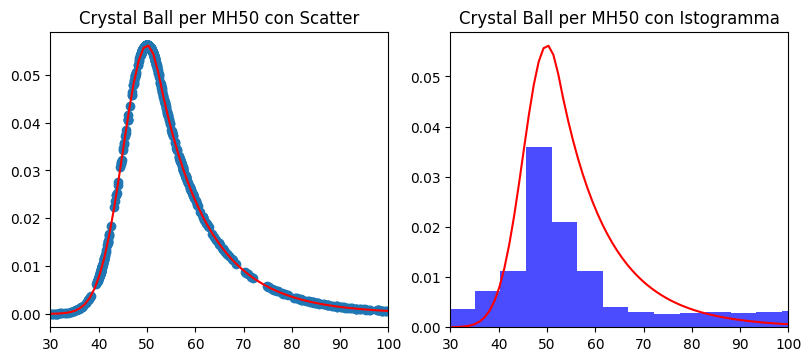

In [18]:
#Importiamo cio' che ci serve
import awkward as ak
import numpy as np
from numba_stats import truncnorm
from scipy.stats import crystalball
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
import matplotlib.pyplot as plt
from Utilities import extractor

# Estraiamo i dati e creiamo il range per il grafico
# Ho creato una funzione per estrarre i dati da ROOT, ho crato un file apposito Utilities nel caso dovesse riservire
x_MH50=list(extractor("Dati/Tprime_tAq_1800_MH50_LH_2017.root", "Events")) 
x_MH50_range=(0, max(x_MH50))

#Check di sicurezza
print(len(x_MH50), type(x_MH50))

#Usiamo le funzioni che ci ha dato Carlo
def cb_pdf(x, mu, sigma, beta, m):
    return crystalball.pdf(-1*x, beta, m, loc=-mu, scale=sigma  )

def neg_log_likelihood(mu, sigma, beta, m ):
    pdf = cb_pdf(x_MH50, mu, sigma, beta, m)
    return -np.sum(np.log(pdf))

#Chiedere al prof che ha fatto qui perché ovviemnte non ricordo 
xl=x_MH50[0:1000]
yl=[ cb_pdf(xi,mu=50,sigma=5,beta=0.5, m=30.0001) for xi in xl]


xm=np.linspace(30,100,70)
ym=cb_pdf(xm,mu=50,sigma=5,beta=0.5, m=30.0001)

fig, ax = plt.subplots(1, 2,figsize=(8, 3.5), sharex=True, constrained_layout=True)

plt.sca(ax[0])
plt.title("Crystal Ball per MH50 con Scatter")
plt.scatter(xl,yl)
plt.plot(xm,ym, color="red")
plt.xlim(30, 100)   


plt.sca(ax[1])
plt.title("Crystal Ball per MH50 con Istogramma")
plt.hist(x_MH50, bins=50, density=True, alpha=0.7, color='blue')
plt.plot(xm,ym, color="red")
plt.xlim(30, 100)









